In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, brier_score_loss,
    ConfusionMatrixDisplay, confusion_matrix,
    RocCurveDisplay
)
from sklearn.calibration import CalibrationDisplay
from xgboost import XGBClassifier

import joblib

df = pd.read_csv("shots_2023.csv")


In [66]:
df.info()
print("\n")
print(df.isnull().sum())
print("\n")
df['goal'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122472 entries, 0 to 122471
Columns: 124 entries, shotID to yCordAdjusted
dtypes: float64(38), int64(73), object(13)
memory usage: 115.9+ MB


shotID                       0
arenaAdjustedShotDistance    0
arenaAdjustedXCord           0
arenaAdjustedXCordABS        0
arenaAdjustedYCord           0
                            ..
xPlayStopped                 0
xRebound                     0
xShotWasOnGoal               0
yCord                        0
yCordAdjusted                0
Length: 124, dtype: int64




goal
0    113899
1      8573
Name: count, dtype: int64

In [67]:
goal_rate = df['goal'].sum() / len(df) * 100
print(f"{goal_rate:.2f}% of our shots result in goals")

7.00% of our shots result in goals


### Important Note for model: 
goals in hockey are scored on **only 7% of shots taken**. This means that if we have a model **classify every shot as a miss**, then our model would be **93% accurate**

In [68]:
df = df[df['shotType'].notna() & (df['shotType'] != 'WRAP')]

In [69]:
df['shootingTeamSkaters'] = np.where(df['isHomeTeam'] == 1, df['homeSkatersOnIce'], df['awaySkatersOnIce'])
df['defendingTeamSkaters'] = np.where(df['isHomeTeam'] == 0, df['homeSkatersOnIce'], df['awaySkatersOnIce'])
df['gameState'] = df['shootingTeamSkaters'].astype(str) + 'v' + df['defendingTeamSkaters'].astype(str)

df['scoreDifferential'] = np.where(df['isHomeTeam'] == 1, df['homeTeamGoals'] - df['awayTeamGoals'], df['awayTeamGoals'] - df['homeTeamGoals'])
df[df['scoreDifferential'].isin(range(-5, 6))]

bins_distance = list(range(0, 110, 10))
labels_distance = [f'{i}-{i+10}' for i in range(0, 100, 10)]
df['distanceBucket'] = pd.cut(df['shotDistance'], bins=bins_distance, labels=labels_distance)

bins_angle = list(range(-95, 95, 10))
labels_angle = []
for i in range (-90, 90, 10):
    if (i < 0):
        labels_angle.append(f'({i})-({i+10})')
    else: 
        labels_angle.append(f'{i}-{i+10}')
df['angleBucket'] = pd.cut(df['shotAngle'], bins=bins_angle, labels=labels_angle)

bins_last_event = list(range(0, 210, 10))
labels_last_event = []
for i in range (0, 200, 10):
    if (i < 0):
        labels_last_event.append(f'({i})-({i+10})')
    else: 
        labels_last_event.append(f'{i}-{i+10}')
df['distanceFromLastEventBucket'] = pd.cut(df['distanceFromLastEvent'], bins=bins_last_event, labels=labels_last_event)

columns = {
    'mean': 'Goal Rate',
    'count': 'Shots',
    'sum': 'Goals'
}

# Exploratory Data Analysis

## Attacking Zone Scatter Plot

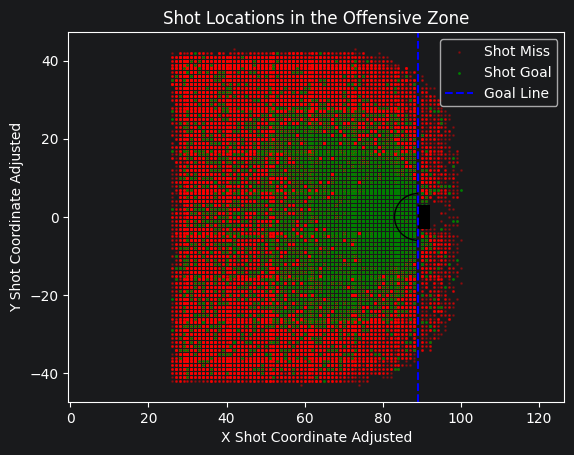

In [70]:
df_shots_in_attacking_zone = df[(df['xCordAdjusted'] > 25)]
shots_in_attacking_zone_x = df_shots_in_attacking_zone['xCordAdjusted']
shots_in_attacking_zone_y = df_shots_in_attacking_zone['yCordAdjusted']

goals_in_attacking_zone = df_shots_in_attacking_zone[(df_shots_in_attacking_zone['goal'] == 1)]
goals_in_attacking_zone_x = goals_in_attacking_zone['xCordAdjusted']
goals_in_attacking_zone_y = goals_in_attacking_zone['yCordAdjusted']

miss_in_attacking_zone = df_shots_in_attacking_zone[(df_shots_in_attacking_zone['goal'] == 0)]
miss_in_attacking_zone_x = miss_in_attacking_zone['xCordAdjusted']
miss_in_attacking_zone_y = miss_in_attacking_zone['yCordAdjusted']

fig, ax = plt.subplots()

ax.scatter(miss_in_attacking_zone_x, miss_in_attacking_zone_y, s=1, alpha=0.3, c='red', label='Shot Miss')
ax.scatter(goals_in_attacking_zone_x, goals_in_attacking_zone_y, s=1, alpha=1, c='green', label='Shot Goal')
ax.axis('equal')
plt.xlabel("X Shot Coordinate Adjusted")
plt.ylabel("Y Shot Coordinate Adjusted")

ax.axvline(x=89, c='blue', label='Goal Line', ls='dashed')
goal = matplotlib.patches.Rectangle((89, -3), 3, 6, fc='black')
ax.add_patch(goal)
crease = matplotlib.patches.Arc((89, 0), 12, 12, theta1=90 , theta2=270 , fill=False, edgecolor='black')
ax.add_patch(crease)

plt.title('Shot Locations in the Offensive Zone')
plt.legend(loc='upper right')
plt.show()

### Insights
Here, I added a scatter plot displaying all shot attempts in the attacking zone of the hockey rink, with non-goal shots in red and goals in green. A clear pattern appears as expected, with goals clustering densely in the area directly in front of the goal, while non-goal shots spread across the entire offensive zone. This suggests that shot location captured through shot-distance and shot-angle can be of the strongest predictors in our xG model.

Chart Design Explanation:
1. Filter shots down to shots taken within the attacking zone, using adjusted coordinates to allow us to view all the data within only one half of the rink.
2. Grab the x and y coordinates of shots-taken and further filter down to x and y coordiantes of goals and misses in the attacking zone
3. Scatter our x and y shot coordinate data, color coding shots scored in green and shots missed in red
4. Add a rectangle to our plot using patches (ax necessary just for rectangle compatibility); add a vertical dashed line representing the goal line; add an arc representing the shot crease.

## Hexbin Heatmaps

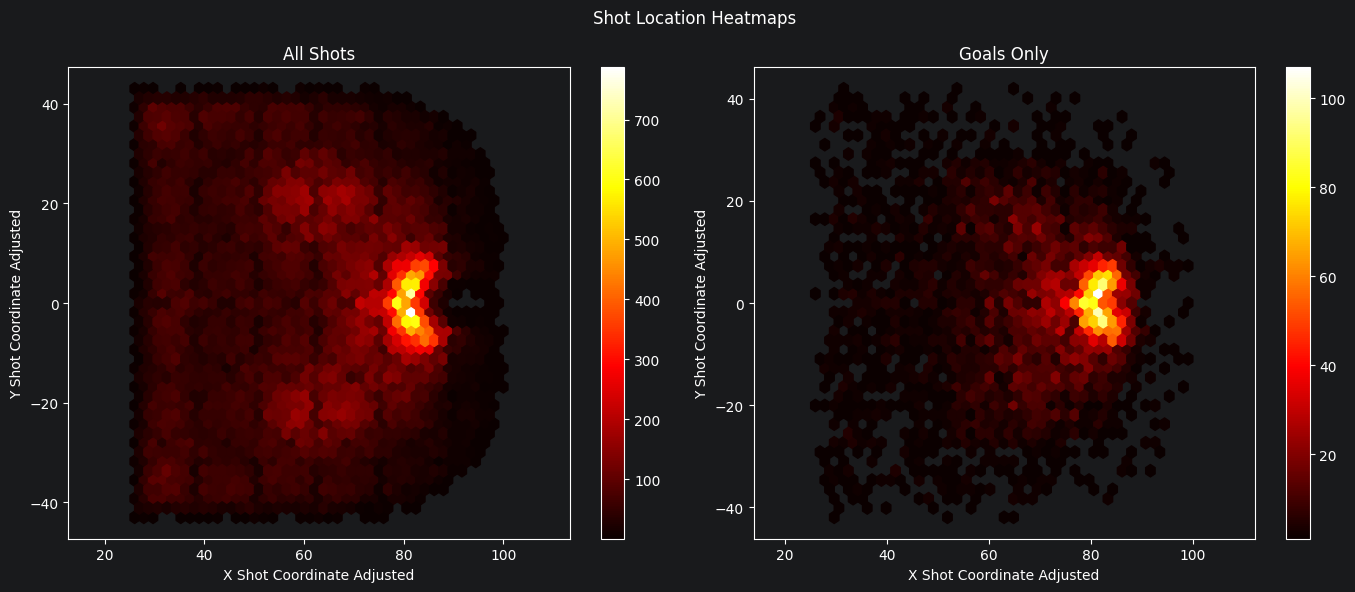

In [71]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.hexbin(shots_in_attacking_zone_x, shots_in_attacking_zone_y, gridsize=40, cmap='hot', mincnt=1)
plt.colorbar()
plt.xlabel("X Shot Coordinate Adjusted")
plt.ylabel("Y Shot Coordinate Adjusted")
plt.title("All Shots")
plt.axis('equal')

plt.subplot(1, 2, 2)
plt.hexbin(goals_in_attacking_zone_x, goals_in_attacking_zone_y, gridsize=40, cmap='hot', mincnt=1)
plt.colorbar()
plt.xlabel("X Shot Coordinate Adjusted")
plt.ylabel("Y Shot Coordinate Adjusted")
plt.title("Goals Only")
plt.axis('equal')

plt.suptitle("Shot Location Heatmaps")
plt.tight_layout()
plt.show()

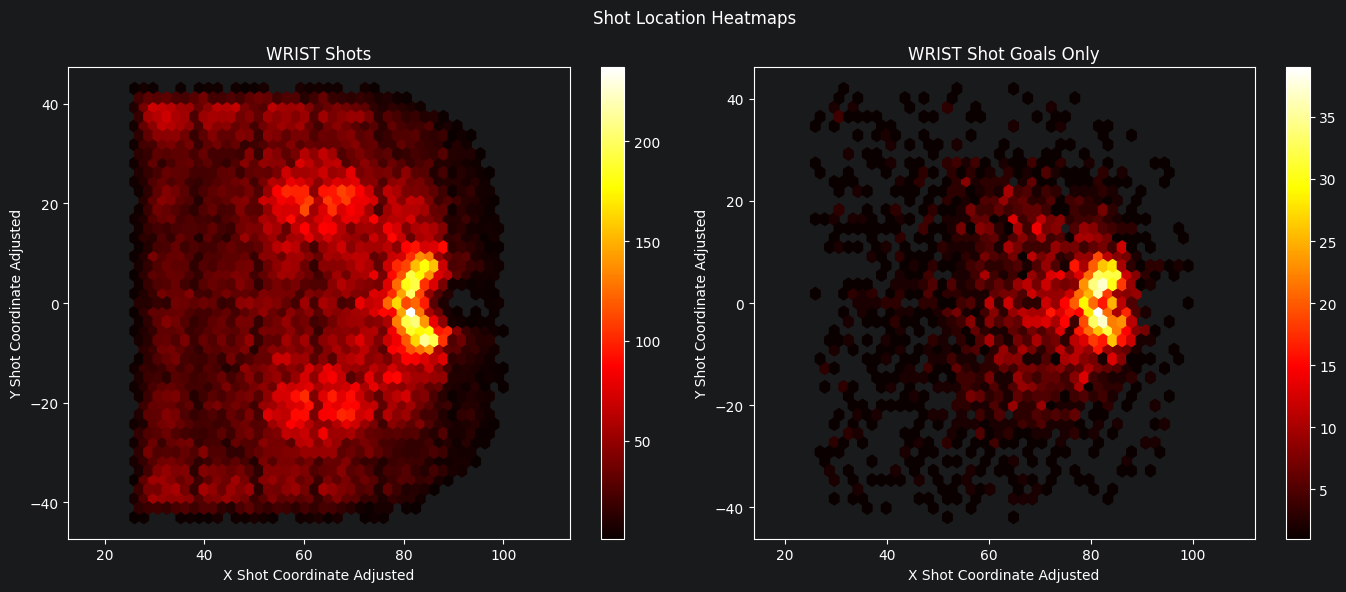

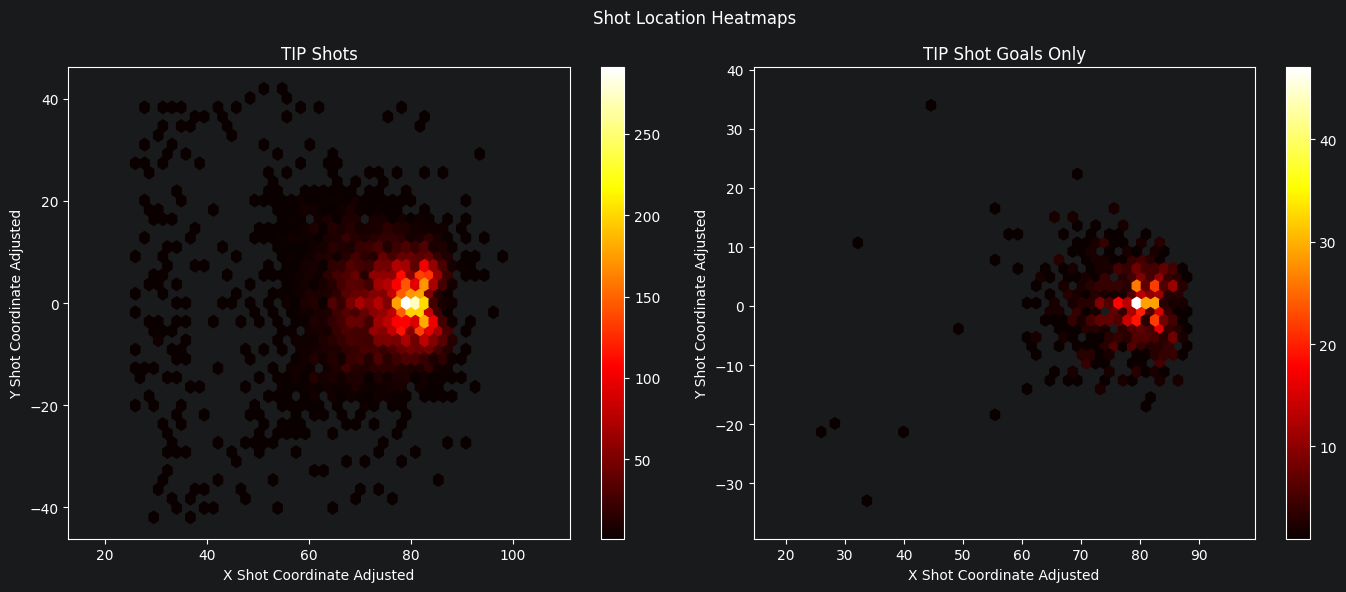

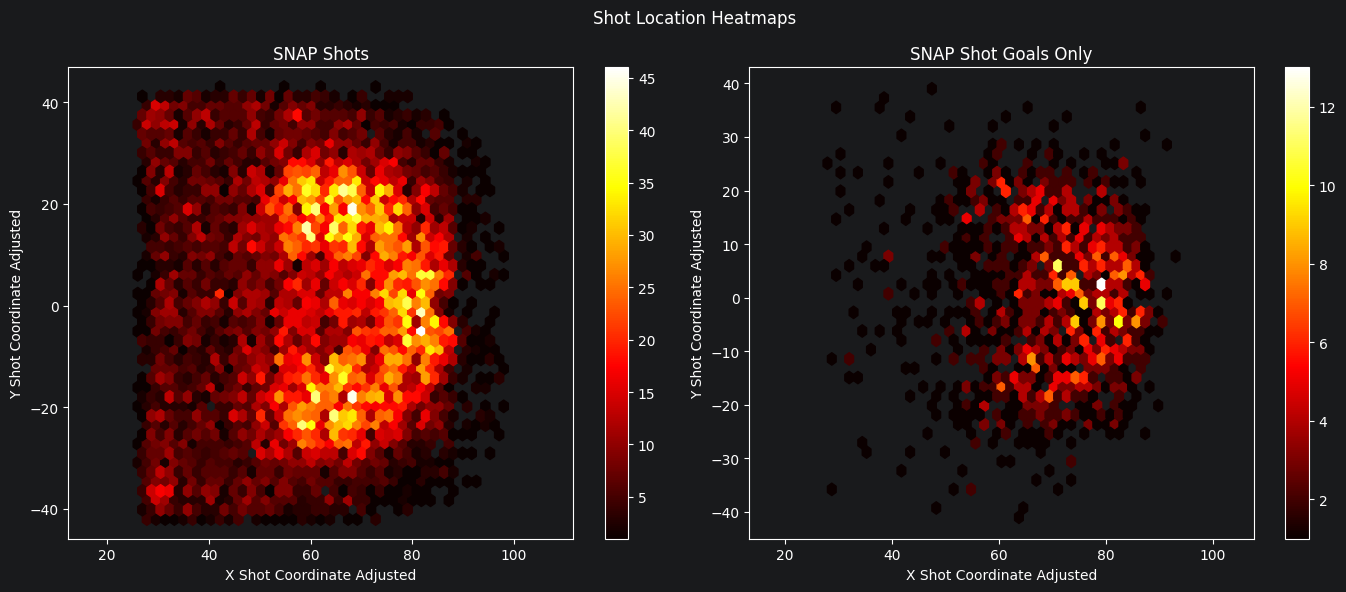

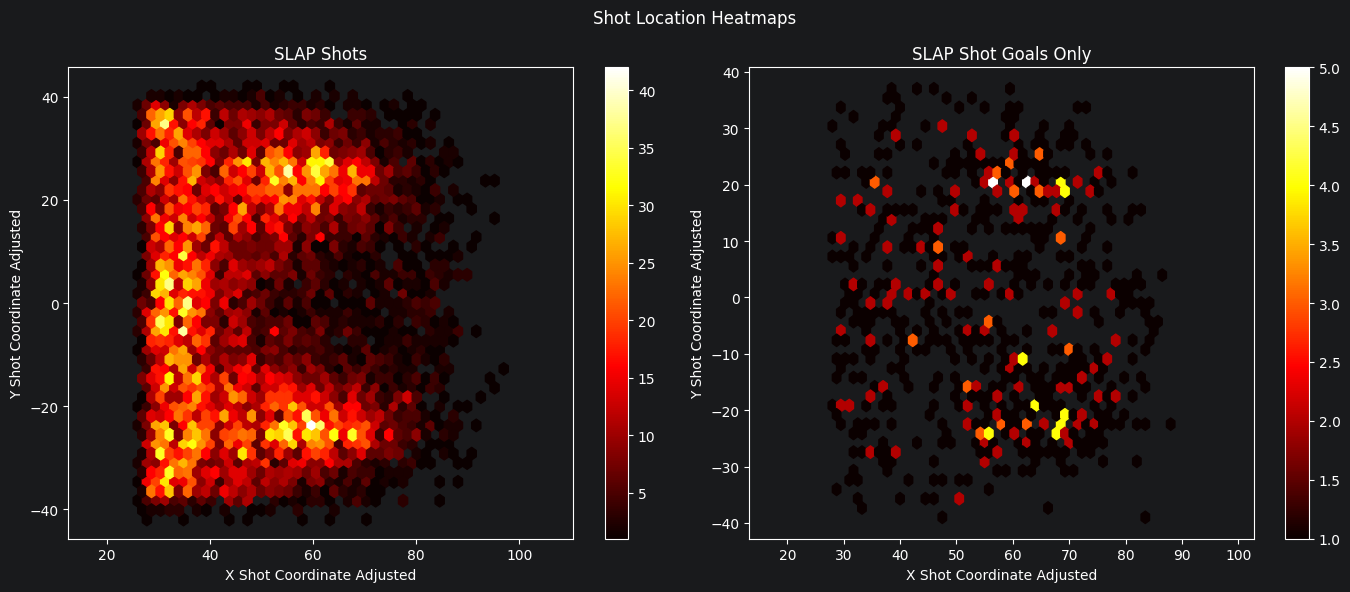

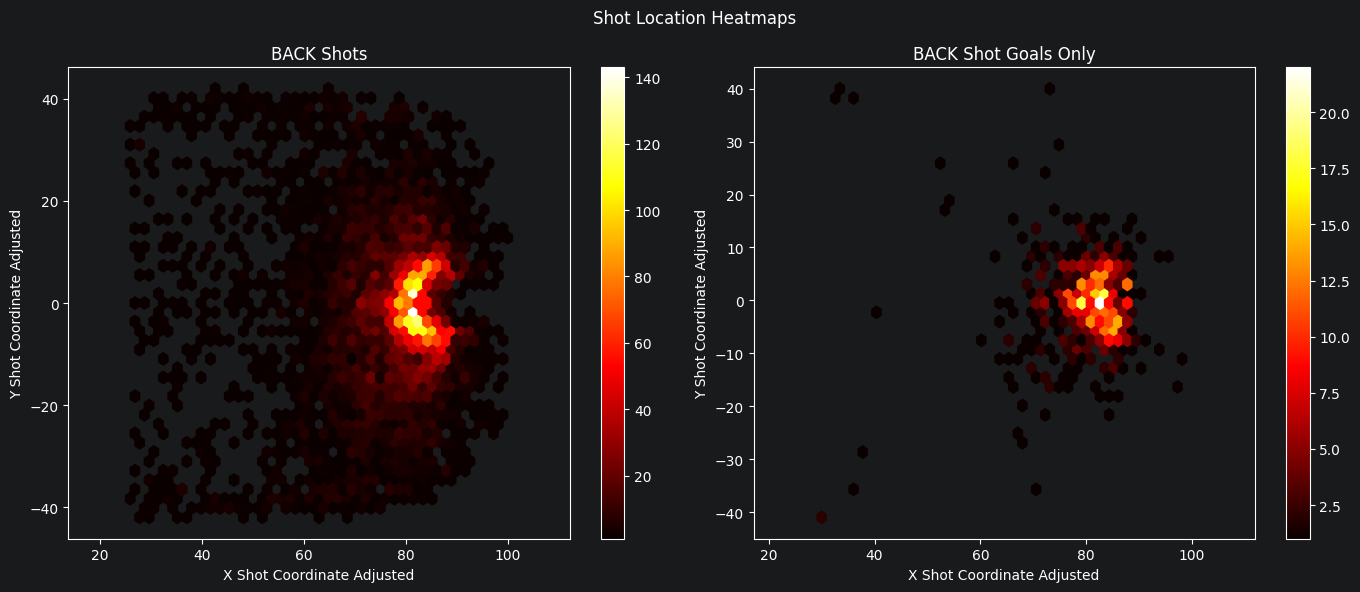

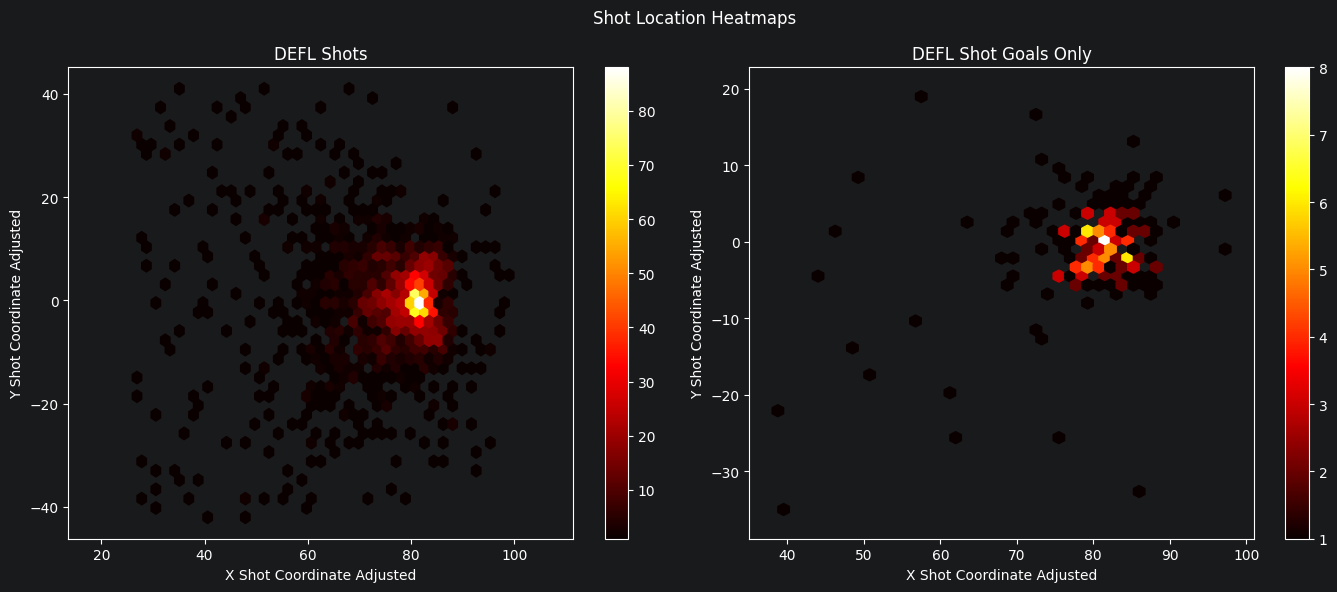

In [72]:
shot_types = [s for s in df_shots_in_attacking_zone['shotType'].unique() if s != 'WRAP' and pd.notna(s)]

for shot_type in shot_types:
    df_shot_type_attacking_zone = df_shots_in_attacking_zone[df_shots_in_attacking_zone['shotType'] == shot_type]
    df_shot_type_goals = df_shot_type_attacking_zone[df_shot_type_attacking_zone['goal'] == 1]

    df_shot_type_attacking_zone_x = df_shot_type_attacking_zone['xCordAdjusted']
    df_shot_type_attacking_zone_y = df_shot_type_attacking_zone['yCordAdjusted']

    goals_in_attacking_zone = df_shot_type_attacking_zone[(df_shot_type_attacking_zone['goal'] == 1)]
    goals_in_attacking_zone_x = goals_in_attacking_zone['xCordAdjusted']
    goals_in_attacking_zone_y = goals_in_attacking_zone['yCordAdjusted']

    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.hexbin(df_shot_type_attacking_zone_x, df_shot_type_attacking_zone_y, gridsize=40, cmap='hot', mincnt=1)
    plt.colorbar()
    plt.xlabel("X Shot Coordinate Adjusted")
    plt.ylabel("Y Shot Coordinate Adjusted")
    plt.title(F"{shot_type} Shots")
    plt.axis('equal')

    plt.subplot(1, 2, 2)
    plt.hexbin(goals_in_attacking_zone_x, goals_in_attacking_zone_y, gridsize=40, cmap='hot', mincnt=1)
    plt.colorbar()
    plt.xlabel("X Shot Coordinate Adjusted")
    plt.ylabel("Y Shot Coordinate Adjusted")
    plt.title(F"{shot_type} Shot Goals Only")
    plt.axis('equal')

    plt.suptitle("Shot Location Heatmaps")
    plt.tight_layout()
    plt.show()

### Insights
Here, I added 2 charts displaying heatmaps of our shot data: the left chart showing the clustering density of all shots taken and the right showing the clustering density of shots taken resulting in goals.
Most shots taken are shots directly in front of goal. On our left heatmap we see an interesting pattern within the shot density with an increase in clustering around the faceoff zones (x=60 and with a slight angle on goal at y=20 and y=-20.)
The right chart (goals only) is far more concentrated near the net than the left chart (all shots).

## Shot Type Analysis

In [73]:
df_shots_with_goalie = df[(df['shotOnEmptyNet'] == 0.0)]

df_shot_type_goal_rate = df[(df['shotOnEmptyNet'] == 0.0)].groupby('shotType')['goal'].agg(['mean', 'count', 'sum']).rename(columns=columns)
df_shot_type_goal_rate.sort_values(by='Goal Rate', ascending=False)


,Goal Rate,Shots,Goals
shotType,,,
SNAP,0.091310,17216,1572
TIP,0.083326,10777,898
DEFL,0.082828,2475,205
BACK,0.079871,8664,692
WRIST,0.057611,66099,3808
SLAP,0.049503,14383,712


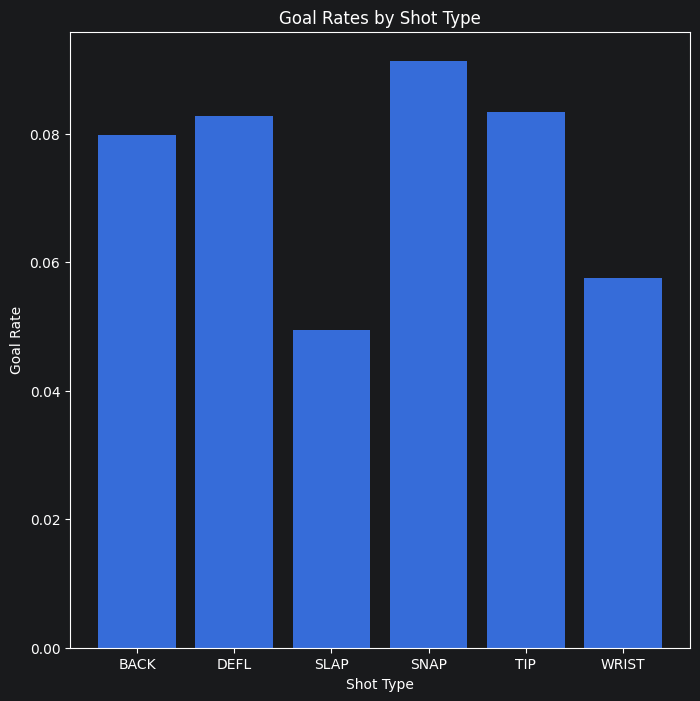

In [74]:
plt.figure(figsize=(8, 8))
plt.bar(df_shot_type_goal_rate.index, df_shot_type_goal_rate[('Goal Rate')])
plt.xlabel('Shot Type')
plt.ylabel('Goal Rate')
plt.title('Goal Rates by Shot Type')
plt.show()

### Insights
Here, I analyze how different shot types influence goal rate. SNAP shots seem to have the highest goal rate while BACKHAND shots, DEFLECTIONS, and TIP shots all have similar goal probabilities around 8%. SLAP shots, WRAP shots, and WRIST shots all have about a 5% goal rate.

## Shot Distance Analysis

In [75]:
df_shot_distance_goal_rate = df.groupby('distanceBucket', observed=[True])['goal'].agg(['mean', 'count', 'sum']).rename(columns=columns)
df_shot_distance_goal_rate

,Goal Rate,Shots,Goals
distanceBucket,,,
0-10,0.147548,14619,2157
10-20,0.110274,20830,2297
20-30,0.089792,19122,1717
30-40,0.051175,21866,1119
40-50,0.030477,16865,514
50-60,0.021776,14236,310
60-70,0.016149,8917,144
70-80,0.030071,1829,55
80-90,0.022545,1375,31


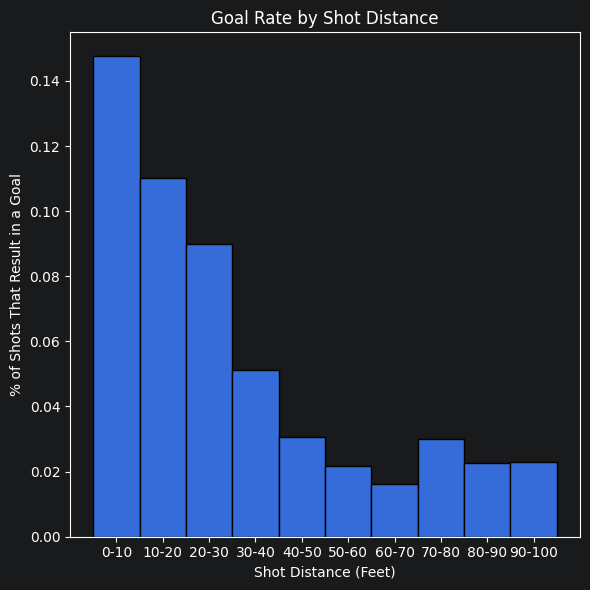

In [76]:
plt.figure(figsize=(6, 6))
plt.bar(df_shot_distance_goal_rate.index, df_shot_distance_goal_rate['Goal Rate'], width=1, edgecolor='black')
plt.xlabel("Shot Distance (Feet)")
plt.ylabel("% of Shots That Result in a Goal")
plt.title("Goal Rate by Shot Distance")
plt.tight_layout()
plt.show()

### Inisights
Here, I binned shot distance into 10 foot ranges and calculated the goal rate per bucket. The chart shows that shot distance and goal rate are inversely related, as shots taken closer to the net have a higher probability of resulting in a goal. The non-linear drop off confirms that a linear model may not sufficiently capture the relationship between shot distance and goal probability.

## Shot Angle Analysis

In [77]:
df_shot_angle_goal_rate = df.groupby('angleBucket', observed=True)['goal'].agg(['mean', 'count', 'sum']).rename(columns=columns)
df_shot_angle_goal_rate

,Goal Rate,Shots,Goals
angleBucket,,,
(-90)-(-80),0.033898,531,18
(-80)-(-70),0.046560,2427,113
(-70)-(-60),0.061004,3049,186
(-60)-(-50),0.068450,4748,325
(-50)-(-40),0.071630,7455,534
(-40)-(-30),0.059210,8833,523
(-30)-(-20),0.061403,11449,703
(-20)-(-10),0.071670,9181,658
(-10)-(0),0.091341,7992,730


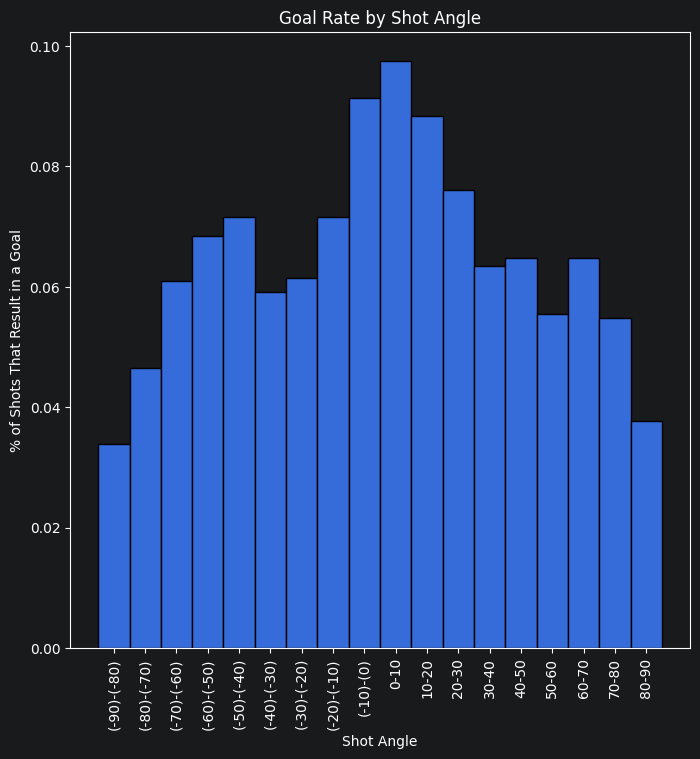

In [78]:
plt.figure(figsize=(8, 8))
plt.bar(df_shot_angle_goal_rate.index, df_shot_angle_goal_rate['Goal Rate'], width=1, edgecolor='black', )
plt.xticks(rotation=90)
plt.xlabel("Shot Angle")
plt.ylabel("% of Shots That Result in a Goal")
plt.title("Goal Rate by Shot Angle")
plt.show()

### Insights
Here, I binned shot angle into 10 degreee ranges and calculated the goal rates per bucket. I used the full range of negative and positvie angles to capture both sides of the ice. Goal rates peak at shots taken directly in front of the net and taper off as the magnitude of the shot angle increases.

## Period Analysis

In [79]:
reg_periods = [1, 2, 3]
df_shots_during_reg_time = df[(df['shotOnEmptyNet'] == 0) & (df['period'].isin(reg_periods))]

df_goal_rate_by_period = df_shots_during_reg_time.groupby('period')['goal'].agg(['mean', 'count', 'sum']).rename(columns=columns)
df_goal_rate_by_period

,Goal Rate,Shots,Goals
period,,,
1,0.062821,38761,2435
2,0.069235,41063,2843
3,0.063138,38186,2411


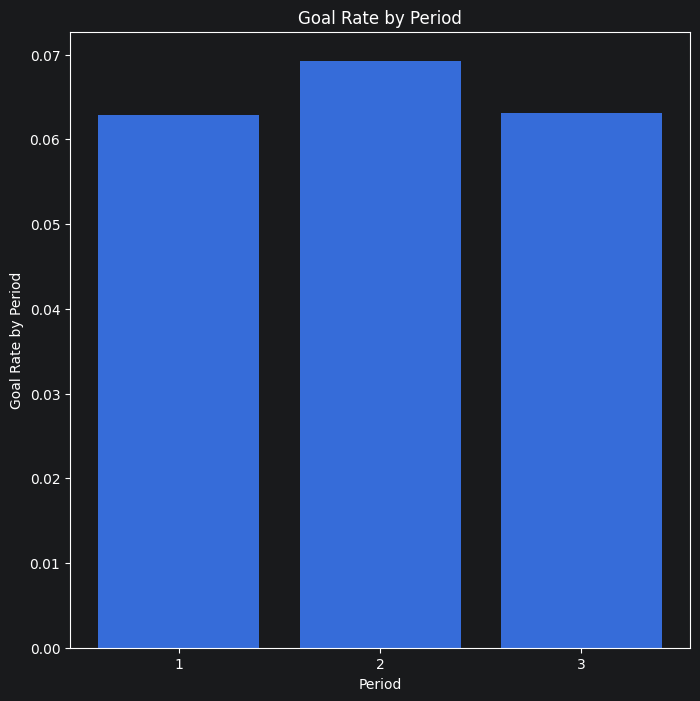

In [80]:
plt.figure(figsize=(8, 8))
plt.bar(df_goal_rate_by_period.index, df_goal_rate_by_period['Goal Rate'])
plt.xticks([1, 2, 3])
plt.xlabel('Period')
plt.ylabel('Goal Rate by Period')
plt.title('Goal Rate by Period')
plt.show()

## Rebound Analysis

In [81]:
df_shot_rebound_goal_rates = df.groupby('shotRebound')['goal'].agg(['mean', 'count', 'sum']).rename(columns=columns)
df_shot_rebound_goal_rates.index = ['No Rebound', 'Rebound']
df_shot_rebound_goal_rates

,Goal Rate,Shots,Goals
No Rebound,0.065739,111867,7354
Rebound,0.117524,8577,1008


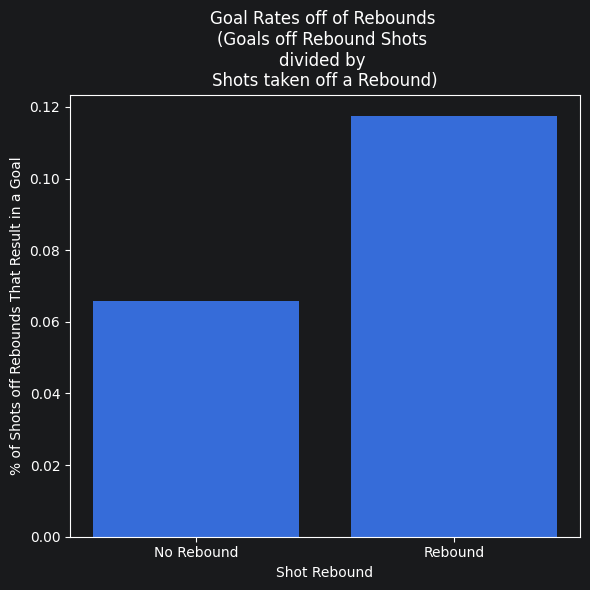

In [82]:
plt.figure(figsize=(6, 6))

plt.bar(df_shot_rebound_goal_rates.index, df_shot_rebound_goal_rates['Goal Rate'])
plt.xlabel("Shot Rebound")
plt.ylabel("% of Shots off Rebounds That Result in a Goal")
plt.title("Goal Rates off of Rebounds \n(Goals off Rebound Shots \ndivided by \nShots taken off a Rebound)")
plt.tight_layout()
plt.show()

### Insights
This chart compares goal rates between rebound shots and non rebound shots, showing significianlty higher goal rates on shots taken off a rebound. This will be a strong and meaningful feature to include in the model.

## Game State Analysis

In [83]:
df_game_state_samples = df[df['gameState'].isin(['5v5', '5v4', '4v5', '4v4'])]
df_goal_rates = df_game_state_samples.groupby('gameState')['goal'].agg(['mean', 'count', 'sum']).rename(columns=columns)
df_goal_rates

,Goal Rate,Shots,Goals
gameState,,,
4v4,0.086341,1413,122
4v5,0.078210,2928,229
5v4,0.093791,16910,1586
5v5,0.058698,93751,5503


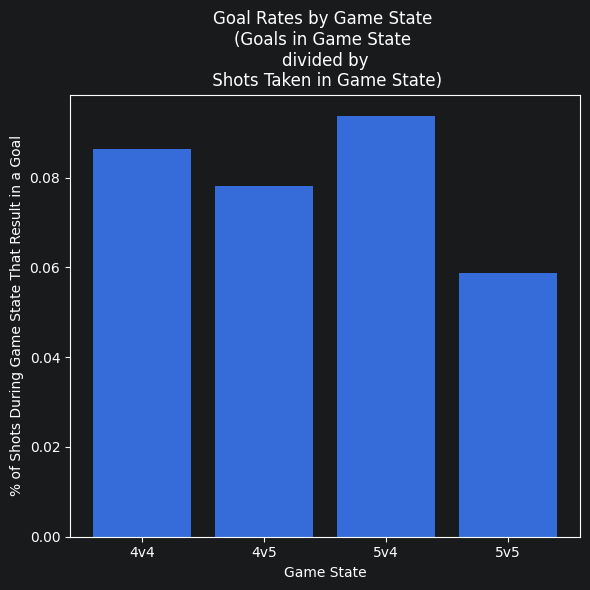

In [84]:
plt.figure(figsize=(6, 6))
plt.bar(df_goal_rates.index, df_goal_rates['Goal Rate'])
plt.xlabel("Game State")
plt.ylabel("% of Shots During Game State That Result in a Goal")
plt.title("Goal Rates by Game State \n(Goals in Game State \ndivided by\n Shots Taken in Game State)")
plt.tight_layout()
plt.show()

### Insights
Here, we analyze the goal rate during different game state situations (filtering out empty net shots). Our chart shows that Power Plays (5v4) have the highest goal rate, then 4v4 situations have the second highest. and oddly shorthanded 4v5 situations have a higher goal rate than standard 5v5 situations, likely due to shorthanded situations having more breakaways or odd-man rushes. Game state impacts shot quality, teams can create higher quality shot opportunities in more advantageous situations, making shootingTeamSkaters and defendingTeamSkaters worth including as model features.

## Off-wing Shot Analysis

In [85]:
df_shot_offWing_goal_rate = df.groupby('offWing')['goal'].agg(['mean', 'count', 'sum']).rename(columns=columns)
df_shot_offWing_goal_rate.index = ['On Wing', 'Off Wing']
df_shot_offWing_goal_rate

,Goal Rate,Shots,Goals
On Wing,0.064033,71370,4570
Off Wing,0.077271,49074,3792


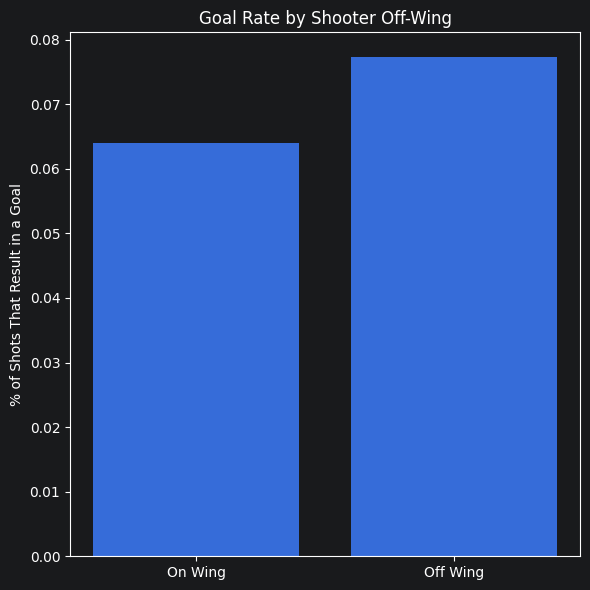

In [86]:
plt.figure(figsize=(6, 6))
plt.bar(df_shot_offWing_goal_rate.index, df_shot_offWing_goal_rate['Goal Rate'])
plt.xlabel("")
plt.ylabel("% of Shots That Result in a Goal")
plt.title("Goal Rate by Shooter Off-Wing")
plt.tight_layout()
plt.show()

### Insights
Here, I analyze goal rates for shots taken on wing and off wing. The chart shows that shots taken off wing have higher goal rates than shots taken on wing. When a player takes a shot while being off-wing, they receive the puck with their forehand more naturally facing the net, allowing them to get a shot off quickly without needing to adjust their body position and allowing their shooting angle to be direct toward the center of the net.
In contrast, a player taking a shot on-wing tends to shoot from a wider angle along the boards, giving the goalie a better look at the puck and more time to set.

### Insights
Here, I wanted to see if goal rates vary by period. My hypothesis was that the 3rd period would have the lowest goal rate by period because teams seeking an equalizer would be taking shots more frantically. The charts show that actually, goal rates don't vary too much across periods and that the 1st and 3rd period observe very similar goal rates. An explanation for why the 2nd period may have the highest goal rate is that teams are able to get through opposing teams defenses over time due to factors such as fatigue and tactical adjustments. In the third period, teams may shift their tactics to lockdown defense with their mission being to maintain their lead over the opposing team.

## Last Event Analysis

In [87]:
df_event_categories = df[(df['lastEventCategory'] != 'CHL') & (df['lastEventCategory'] != 'STOP')].copy()
df_event_categories['lastEventCategory'] = df_event_categories['lastEventCategory'].replace('DELPEN', 'DELAYED PENALTY').replace('FAC', 'FACEOFF').replace('GIVE', 'GIVEAWAY')
df_goal_rate_last_event_category = df_event_categories.groupby('lastEventCategory')['goal'].agg(['mean', 'count', 'sum']).rename(columns=columns)
df_goal_rate_last_event_category

,Goal Rate,Shots,Goals
lastEventCategory,,,
BLOCK,0.070471,16858,1188
DELAYED PENALTY,0.148148,594,88
FACEOFF,0.054171,30496,1652
GIVEAWAY,0.087791,9067,796
HIT,0.054342,19690,1070
MISS,0.072418,13422,972
SHOT,0.084979,22382,1902
TAKE,0.086896,7929,689


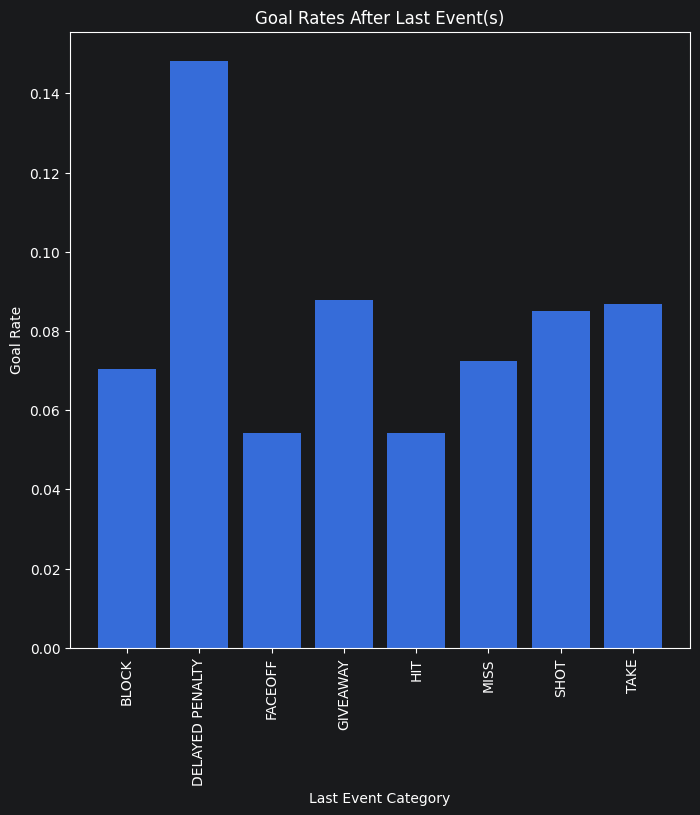

In [88]:
plt.figure(figsize=(8, 8))
plt.bar(df_goal_rate_last_event_category.index, df_goal_rate_last_event_category['Goal Rate'])
plt.xticks(rotation=90)
plt.xlabel('Last Event Category')
plt.ylabel('Goal Rate')
plt.title('Goal Rates After Last Event(s)')
plt.show()

### Insights
Here, I analyze how goal rates change based on the last event that occurred leading up to a shot. Shots occurring after a delayed penalty have the highest goal rate.

## Distance From Last Event Leading to Shot Analysis

In [89]:
df_distance_from_last_event_goal_rate = df.groupby('distanceFromLastEventBucket', observed=True)['goal'].agg(['mean', 'count', 'sum']).rename(columns=columns)
df_distance_from_last_event_goal_rate

,Goal Rate,Shots,Goals
distanceFromLastEventBucket,,,
0-10,0.101143,8226,832
10-20,0.086578,13202,1143
20-30,0.083732,15275,1279
30-40,0.069174,15367,1063
40-50,0.057080,13087,747
50-60,0.052071,9948,518
60-70,0.043450,7664,333
70-80,0.044834,5130,230
80-90,0.053100,3823,203


Text(0.5, 1.0, 'Goal Rate vs Distance From Last Event')

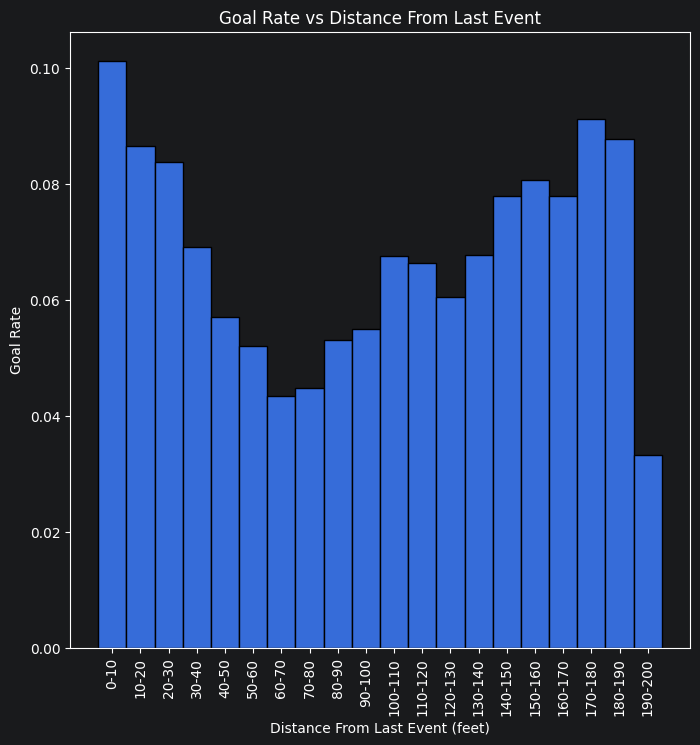

In [90]:
plt.figure(figsize=(8,8))
plt.bar(df_distance_from_last_event_goal_rate.index, df_distance_from_last_event_goal_rate['Goal Rate'], width=1, edgecolor='black', )
plt.xticks(rotation=90)
plt.xlabel('Distance From Last Event (feet)')
plt.ylabel('Goal Rate')
plt.title('Goal Rate vs Distance From Last Event')

### Insights
Here, I look at how the distance between where the last event occurred and where the consecutive shot is taken impacts goal rates. I binned distance from last event in to groups of 10 ft.

## Score Differential Analysis

In [91]:
df_score_differential_goal_rate = df[df['scoreDifferential'].isin(range(-5, 6))].groupby('scoreDifferential')['goal'].agg(['mean', 'count', 'sum']).rename(columns=columns)
df_score_differential_goal_rate

,Goal Rate,Shots,Goals
scoreDifferential,,,
-5,0.050617,810,41
-4,0.060853,2087,127
-3,0.060324,5255,317
-2,0.060991,11969,730
-1,0.064702,22163,1434
0,0.064806,41786,2708
1,0.079739,19476,1553
2,0.092573,9560,885
3,0.082276,4254,350


Text(0.5, 1.0, 'Goal Rate vs Score Differential')

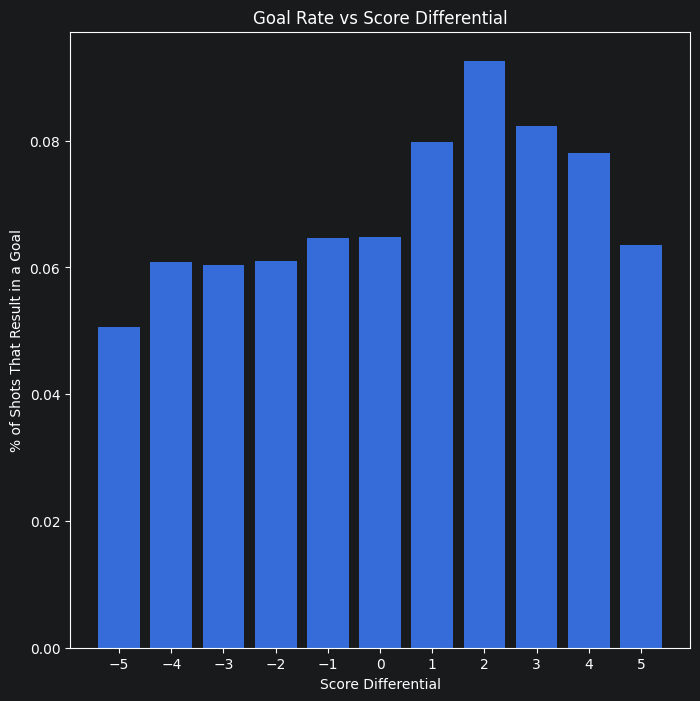

In [92]:
plt.figure(figsize=(8,8))
plt.bar(df_score_differential_goal_rate.index, df_score_differential_goal_rate['Goal Rate'])
plt.xticks(range(-5, 6))
plt.xlabel('Score Differential')
plt.ylabel('% of Shots That Result in a Goal')
plt.title('Goal Rate vs Score Differential')

### Insights
Here, we analyze the score differential between the two teams at the time of the shot. We find that teams with a positive 2 goal differential have the highest goal rate. When a team is leading by 1-2 goals, the trailing team is pressing forward aggressively, leaving gaps in their defensive zone. This creates high quality counter-attack opportunities for the leading team. 

## Shot Type x Distance Heatmap

In [93]:
bins = list(range(0, 110, 10))
labels = [f'{i}-{i+10}' for i in range(0, 100, 10)]
df['distanceBucket'] = pd.cut(df['shotDistance'], bins=bins, labels=labels)

df_shot_type_by_distance_goal_rate = df.groupby(['shotType', 'distanceBucket'], observed=True)['goal'].agg(['mean', 'count', 'sum']).rename(columns=columns)
df_unstacked = df_shot_type_by_distance_goal_rate['Goal Rate'].unstack(level=0)

Text(0.5, 1.0, 'Goal Rate by Shot Type and \nDistance (2023 NHL Season)')

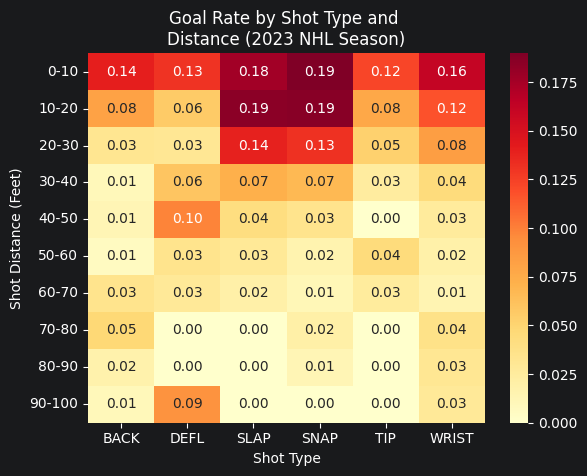

In [94]:
sns.heatmap(df_unstacked, annot=True, fmt='.2f', cmap='YlOrRd')
plt.xlabel("Shot Type")
plt.ylabel("Shot Distance (Feet)")
plt.title("Goal Rate by Shot Type and \nDistance (2023 NHL Season)")

### Insights
Here, I cross-reference shot type and shot distance to examine how goal rates vary across both dimensions simultaneously. A few patterns stand out:

- **Tip and deflection shots are almost exclusively dangerous at close range.** TIP and DEFL shots convert at high rates within 20ft, which makes sense — these shots rely on redirecting a pass and are typically set up in front of the net.
- **Snap shots** outperform wrist shots at most distances, likely because the quicker release gives goalies less time to set.
- **Slap shots** show the sharpest drop-off with distance — they convert reasonably well inside 30ft but become low-probability beyond that range.
- **Backhand shots** are concentrated close to the net and carry a solid conversion rate, consistent with wraparound and breakaway situations.
- The highest goal rates appear in the top-left of the heatmap (close range + contact shot types), while the bottom-right (long range + hard shot types) are near zero.

This confirms that **shot type and distance are not independent** — including both as features captures interactions that neither variable captures alone.

## Features Correlations and Matrices

In [95]:
df_numeric_features = df[['shotDistance', 'shotAngleAdjusted', 'shotRebound', 'offWing', 'shootingTeamSkaters', 'defendingTeamSkaters', 'period', 'distanceFromLastEvent', 'goal']]
corr_matrix = df_numeric_features.corr()
corr_matrix

,shotDistance,shotAngleAdjusted,shotRebound,offWing,shootingTeamSkaters,defendingTeamSkaters,period,distanceFromLastEvent,goal
shotDistance,1.000000,-0.234978,-0.260261,-0.149457,0.032443,0.129810,-0.006648,0.069915,-0.161753
shotAngleAdjusted,-0.234978,1.000000,0.081527,0.041444,0.004526,0.043384,0.002476,0.071490,-0.046788
shotRebound,-0.260261,0.081527,1.000000,0.022823,0.031446,-0.008016,-0.006015,-0.206864,0.052396
offWing,-0.149457,0.041444,0.022823,1.000000,-0.006204,-0.096003,0.014878,-0.051122,0.025592
shootingTeamSkaters,0.032443,0.004526,0.031446,-0.006204,1.000000,0.322466,-0.085424,-0.106477,-0.024151
defendingTeamSkaters,0.129810,0.043384,-0.008016,-0.096003,0.322466,1.000000,-0.091578,0.174767,-0.022303
period,-0.006648,0.002476,-0.006015,0.014878,-0.085424,-0.091578,1.000000,-0.003674,0.023802
distanceFromLastEvent,0.069915,0.071490,-0.206864,-0.051122,-0.106477,0.174767,-0.003674,1.000000,-0.019204
goal,-0.161753,-0.046788,0.052396,0.025592,-0.024151,-0.022303,0.023802,-0.019204,1.000000


Text(0.5, 1.0, 'Correlation Heatmap of Features')

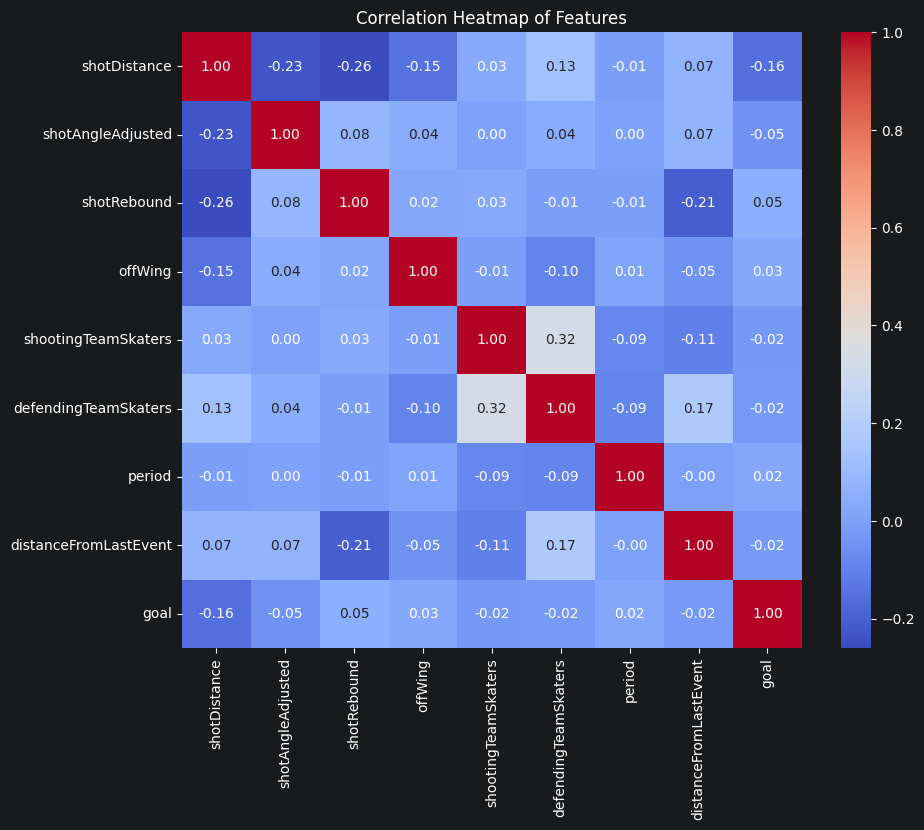

In [96]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap of Features")

Text(0.5, 1.0, 'Correlation Heatmap of Categorical Features')

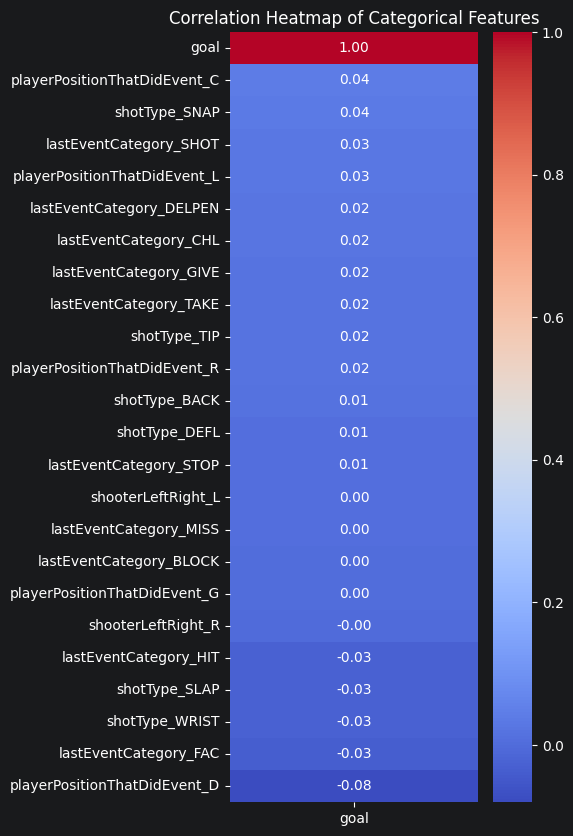

In [97]:
df_categorical_features = df[['shotType', 'lastEventCategory', 'shooterLeftRight', 'playerPositionThatDidEvent', 'goal']]
df_categorical_features = pd.get_dummies(df_categorical_features, drop_first=False)
corr_matrix = df_categorical_features.corr()[['goal']].sort_values(by='goal', ascending=False)
plt.figure(figsize=(4, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap of Categorical Features")

## Feature Selection

After completing our EDA, we selected the following features for the model. The guiding principle was to include features that: (1) showed a meaningful relationship with goal rate in our analysis, and (2) can realistically be provided as inputs on the frontend — either derived from a rink click or selected through a dropdown/toggle.

---

### Features Included

| Feature | Type | Why Included |
|---|---|---|
| `shotDistance` | Numeric | Strongest single predictor — goal rate drops from 14.4% at 0-10ft to under 3% beyond 50ft |
| `shotAngleAdjusted` | Numeric | Goal rate peaks near 0° and tapers with angle magnitude; using absolute angle captures the symmetric bell curve |
| `shotType` | Categorical | Meaningful variation across shot types (SNAP: 9.1% vs SLAP: 5.0%); one-hot encoded |
| `shotRebound` | Binary | Nearly doubles goal rate (11.9% vs 6.6%) — one of the strongest signals in the dataset |
| `offWing` | Binary | Off-wing shots convert at 7.7% vs 6.5% on-wing, due to more natural shooting angle |
| `shootingTeamSkaters` | Numeric | Captures game state — power plays (5v4) have the highest goal rate at 9.5% |
| `defendingTeamSkaters` | Numeric | Required alongside `shootingTeamSkaters` to fully encode the game state |
| `period` | Numeric | Minor variation (2nd period slightly elevated); included as a lightweight contextual signal |
| `distanceFromLastEvent` | Numeric | Shots following a short-distance event (0-10ft) convert at 10.3% — suggests transition plays |
| `scoreDifferential` | Numeric | Leading teams generate higher quality chances as trailing teams press and leave gaps |

---

### Features Excluded

| Feature | Why Excluded |
|---|---|
| `shotRush` | Only 120 rush shots in the dataset — far too small a sample to be a reliable signal |
| `lastEventCategory` | Showed signal in EDA but including it in the model hurt calibration — the category information is partially captured by `distanceFromLastEvent` |
| `shooterLeftRight` | `offWing` already encodes the relevant interaction between handedness and shot side — no need for both |
| `playerPositionThatDidEvent` | Weak correlation with goal rate; too noisy to justify inclusion |

---

Distance and angle are derived automatically from wherever the user clicks on the rink. Shot type, rebound, off-wing, game state, and score differential are exposed as dropdowns and toggles on the frontend.

In [98]:
numeric_features = ['shotDistance', 'shotAngleAdjusted', 'shootingTeamSkaters', 'defendingTeamSkaters', 'period', 'distanceFromLastEvent', 'scoreDifferential']
categorical_features = ['shotType']
binary_features = ['shotRebound', 'offWing']
X = df[numeric_features + categorical_features + binary_features] # WIP: Atul - Maybe split the dataframe into goals and no goals and take a random sample of 75% goals and 25% goals
X = pd.get_dummies(X, columns=['shotType'], dtype=int)
X.head()

,shotDistance,shotAngleAdjusted,shootingTeamSkaters,defendingTeamSkaters,period,distanceFromLastEvent,scoreDifferential,shotRebound,offWing,shotType_BACK,shotType_DEFL,shotType_SLAP,shotType_SNAP,shotType_TIP,shotType_WRIST
0,39.698866,40.914383,5,5,1,56.035703,0,0,0,0,0,0,0,0,1
1,11.313708,45.000000,5,5,1,40.496913,0,0,1,0,0,0,0,1,0
2,45.343136,41.423666,5,5,1,120.432554,0,0,0,0,0,0,1,0,0
3,43.139309,44.060809,5,5,1,21.213203,0,0,1,0,0,0,0,0,1
4,42.201896,53.673174,5,5,1,129.799846,0,0,0,0,0,0,0,0,1


## Model Building - Logistic Regression

In [99]:
scaler = StandardScaler()

# X defined in the cell above
y=df['goal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

y_probability_lr = lr_model.predict_proba(X_test)[:, 1]

### Building the Logistic Regression Model

To begin, I split our feature matrix `X` and target variable `y` into training and test sets using an 80/20 split. The `stratify=y` argument ensures that the 7% goal rate is preserved in both the train and test sets — without it, a random sampling could produce a test set with a slightly different goal rate, making our evaluation metrics less reliable.

Before fitting the model, I apply `StandardScaler` to the numeric features. Logistic regression is sensitive to the scale of input features — a feature like `shotDistance` (ranging 0-100ft) would dominate a feature like `offWing` (0 or 1) if left unscaled. The scaler transforms each numeric feature to have a mean of 0 and standard deviation of 1. I call `fit_transform()` on the training set and only `transform()` on the test set — fitting on the test set would leak information about the test distribution into the model, invalidating our evaluation.

I then initialize a `LogisticRegression` model and fit it on the scaled training data. Finally, `predict_proba()` returns the model's predicted probability for each shot — this is our xG value, not a binary yes/no prediction.

In [100]:
roc_auc = roc_auc_score(y_test, y_probability_lr)
brier = brier_score_loss(y_test, y_probability_lr)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Brier Score: {brier:.4f}")

ROC-AUC: 0.7352
Brier Score: 0.0616


Since xG is a probability output rather than a binary classification prediction, standard accuracy is not as meaningful here as a model that predicts "no goal" on every shot would be 93% accurate.

### ROC-AUC (0.72)
ROC-AUC measures how well the model distinguishes between shots that are goals and shots that are missed. If you randomly select one shot that was a goal and one that wasn't, AUC is the probability that the model assigned a higher xG to the shot resulting in a goal. This means that 72% of the time our model correctly ranks the goal shot. 

### Brier Score (0.0624)
Brier score measures the accuracy of the predicted probabilities (our xG values). the brier score is the mean squared error between predicted probabiity (xG) and the actual outcome (0 or 1). Lower is better and 0 is perfect. A naive model that predicts the league average goal rate (7%) for every shot scores ~0.065, so our model at 0.0624 meaningfully outperforms the baseline.

              precision    recall  f1-score   support

           0       0.96      0.79      0.87     22417
           1       0.16      0.51      0.24      1672

    accuracy                           0.77     24089
   macro avg       0.56      0.65      0.55     24089
weighted avg       0.90      0.77      0.82     24089



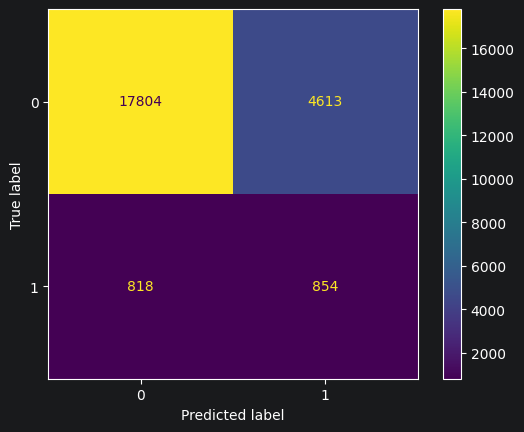

In [101]:
actual = y_test

threshold = 0.1
y_pred_custom = (y_probability_lr >= threshold).astype(int)
print(classification_report(y_test, y_pred_custom))

confusion_matrix_lr = confusion_matrix(actual, y_pred_custom)

cm_display = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_lr, display_labels = [0, 1])

cm_display.plot()
plt.show()

- TN: 22,780 (0, 0) - Correctly predicted no goal
- FN: 0 (1, 0) - Never falsely predicted a goal
- FP: 1,713 (0, 1) - Missed almost every actual goal
- TP: 2 (1, 1) - Correctly identified only 2 goals out of 1,715

This confusion matrix illustrates why hard binary classification is the wrong framing for xG. My model isn't meant to predict a YES or a NO, it's supposed to output a probability. The model's 0.5 default threshold is way too high for a 7% goal rate problem

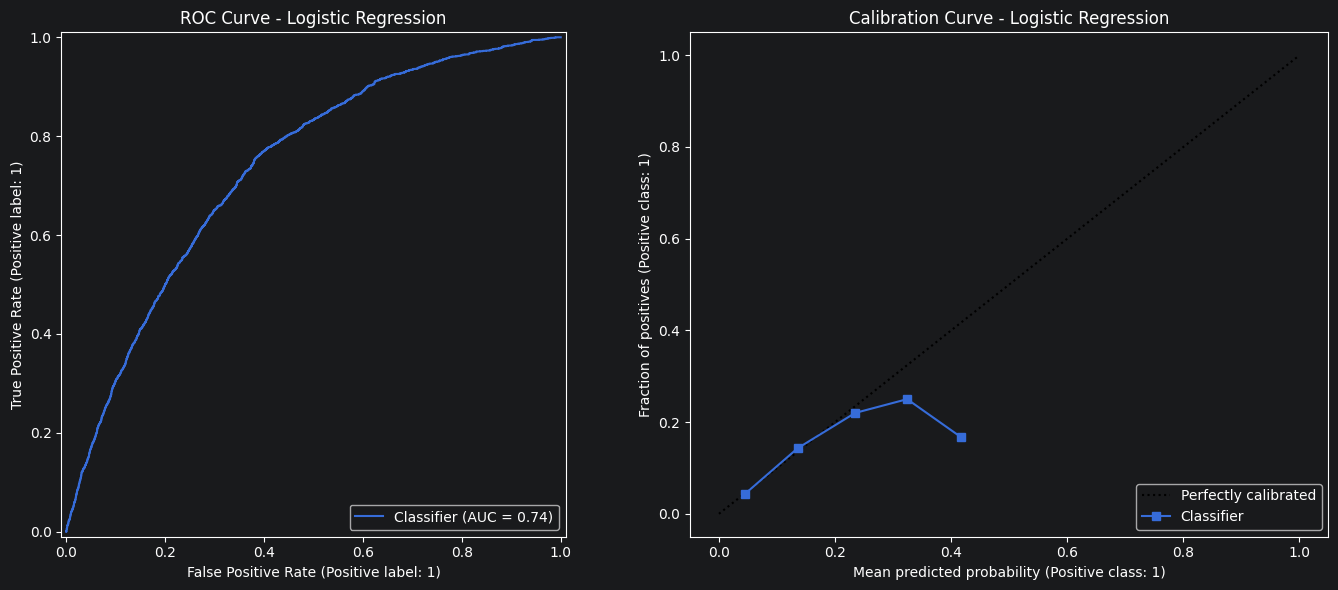

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_probability_lr, ax=axes[0])
axes[0].set_title('ROC Curve - Logistic Regression')

# Calibration Curve
CalibrationDisplay.from_predictions(y_test, y_probability_lr, n_bins=10, ax=axes[1])
axes[1].set_title('Calibration Curve - Logistic Regression')

plt.tight_layout()
plt.show()

### ROC Curve & Calibration Curve

**ROC Curve**
The ROC curve plots the true positive rate against the false positive rate at every possible classification threshold. The AUC of 0.72 means that 72% of the time, our model correctly assigns a higher xG to a shot that resulted in a goal than to one that didn't. A random model scores 0.5, a perfect model scores 1.0.

**Calibration Curve**
The calibration curve measures whether our predicted probabilities are trustworthy as actual probabilities. 
- **X-axis:** the xG values our model outputs, grouped into bins
- **Y-axis:** of all shots in that bin, what fraction actually resulted in a goal

A perfectly calibrated model follows the dotted line — a bin where the model predicts 0.2 xG should contain exactly 20% goals. Our model follows the dotted line reasonably well in the low probability range (0.0–0.2), which is where the vast majority of shots live. The line gets noisier at higher probabilities because far fewer shots fall in those bins, so each data point represents a smaller sample.

Good calibration is important for xG specifically — we're not just ranking shots, we're outputting a number that should be interpretable as a real probability.

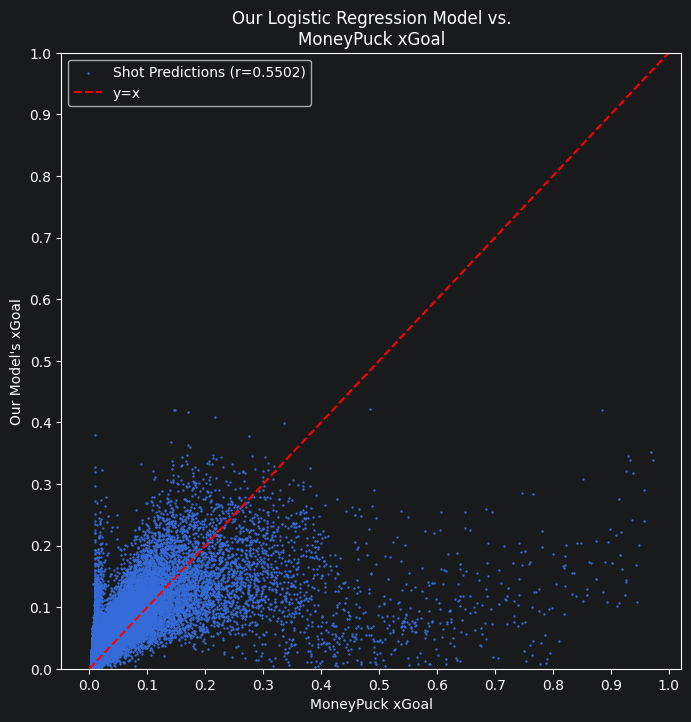

[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
Pearson Correlation: 0.5502


In [103]:
xgoal_moneypuck = df.loc[X_test.index, 'xGoal']
plt.figure(figsize=(8, 8))
ticks = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
correlation = np.corrcoef(xgoal_moneypuck, y_probability_lr)[0, 1]
plt.scatter(xgoal_moneypuck, y_probability_lr, s=.5, label=f'Shot Predictions (r={correlation:.4f})')
plt.xlabel('MoneyPuck xGoal')
plt.ylabel('Our Model\'s xGoal')
plt.xticks(ticks, ticks)
plt.yticks(ticks, ticks)
plt.title('Our Logistic Regression Model vs.\nMoneyPuck xGoal')
plt.axline((0, 0), slope=1, color='red', linestyle='--', label='y=x')
plt.ylim(0, 1)
plt.legend()
plt.show()
print(ticks)

print(f"Pearson Correlation: {correlation:.4f}")

### Benchmarking Against MoneyPuck xGoal

Here, I benchmark our logistic regression model against MoneyPuck's pre-computed xGoal values. Each point represents a single shot from the test set, with our model's predicted xG on the y-axis and MoneyPuck's xGoal on the x-axis. If our model were a perfect match, all points would fall on the y=x line.

The scatter plot shows reasonable agreement in the low probability range (0.0–0.2), where the bulk of shots live. However, our model consistently under-predicts on high-danger shots — MoneyPuck assigns xGoal values up to 1.0 on the most dangerous chances, while our model caps out around 0.4. This is a known limitation of logistic regression: it learns a linear decision boundary and cannot assign extreme probabilities the way a tree-based model can. MoneyPuck's model is also trained on a richer feature set.

The Pearson correlation of {correlation:.4f} confirms that the two models are in broad agreement on shot ranking, even if the absolute probability values diverge at the high end. Random Forest and XGBoost, which we train next, should close this gap.

## Random Forest Model

In [104]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_probability_rf = rf_model.predict_proba(X_test)[:, 1]
y_probability_rf[:10]

array([0.  , 0.  , 0.04, 0.24, 0.08, 0.35, 0.04, 0.01, 0.18, 0.  ])

In [105]:
roc_auc = roc_auc_score(y_test, y_probability_rf)
brier = brier_score_loss(y_test, y_probability_rf)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Brier Score: {brier:.4f}")

ROC-AUC: 0.7193
Brier Score: 0.0635


              precision    recall  f1-score   support

           0       0.96      0.76      0.85     22417
           1       0.14      0.55      0.23      1672

    accuracy                           0.74     24089
   macro avg       0.55      0.65      0.54     24089
weighted avg       0.90      0.74      0.80     24089



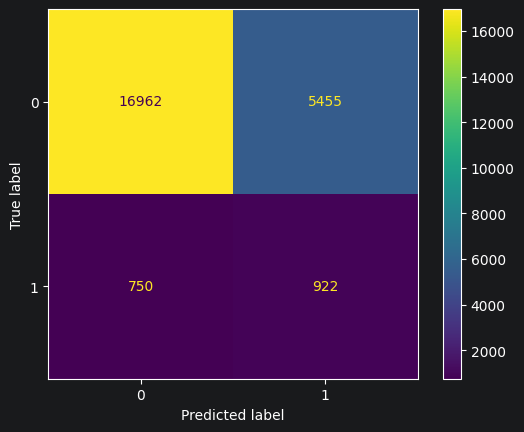

In [106]:
actual = y_test

threshold = 0.1
y_pred_custom = (y_probability_rf >= threshold).astype(int)
print(classification_report(y_test, y_pred_custom))

confusion_matrix_rf = confusion_matrix(actual, y_pred_custom)
cm_display = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_rf, display_labels=[0, 1])
cm_display.plot()
plt.show()

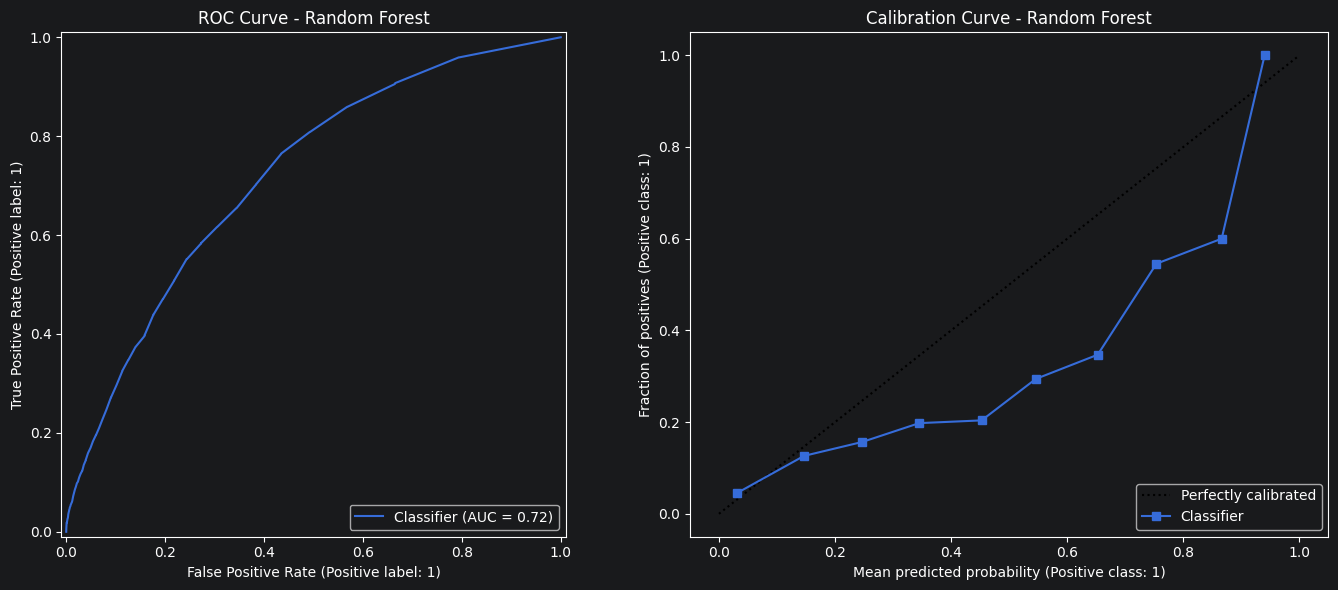

In [107]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_probability_rf, ax=axes[0])
axes[0].set_title('ROC Curve - Random Forest')

# Calibration Curve
CalibrationDisplay.from_predictions(y_test, y_probability_rf, n_bins=10, ax=axes[1])
axes[1].set_title('Calibration Curve - Random Forest')

plt.tight_layout()
plt.show()

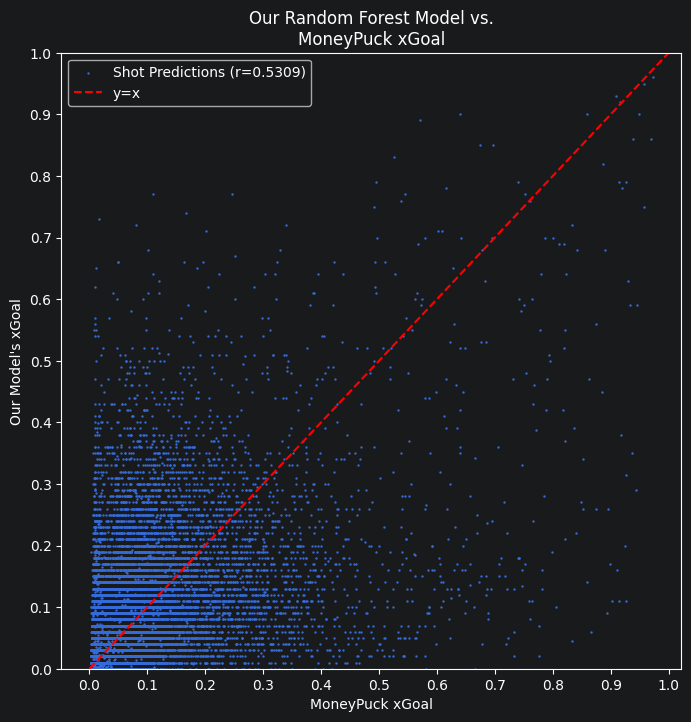

[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
Pearson Correlation: 0.5309


In [108]:
xgoal_moneypuck = df.loc[X_test.index, 'xGoal']
plt.figure(figsize=(8, 8))
ticks = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
correlation = np.corrcoef(xgoal_moneypuck, y_probability_rf)[0, 1]
plt.scatter(xgoal_moneypuck, y_probability_rf, s=.5, label=f'Shot Predictions (r={correlation:.4f})')
plt.xlabel('MoneyPuck xGoal')
plt.ylabel('Our Model\'s xGoal')
plt.xticks(ticks, ticks)
plt.yticks(ticks, ticks)
plt.title('Our Random Forest Model vs.\nMoneyPuck xGoal')
plt.axline((0, 0), slope=1, color='red', linestyle='--', label='y=x')
plt.ylim(0, 1)
plt.legend()
plt.show()
print(ticks)

print(f"Pearson Correlation: {correlation:.4f}")

## XGBoost

In [109]:
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_probability_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_probability_xgb[:10]

array([0.00171018, 0.0310915 , 0.09529959, 0.16953477, 0.05814911,
       0.11591189, 0.03917905, 0.00200805, 0.17918067, 0.00185665],
      dtype=float32)

In [110]:
roc_auc = roc_auc_score(y_test, y_probability_xgb)
brier = brier_score_loss(y_test, y_probability_xgb)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Brier Score: {brier:.4f}")

ROC-AUC: 0.7518
Brier Score: 0.0608


              precision    recall  f1-score   support

           0       0.96      0.78      0.86     22417
           1       0.16      0.56      0.25      1672

    accuracy                           0.77     24089
   macro avg       0.56      0.67      0.56     24089
weighted avg       0.90      0.77      0.82     24089



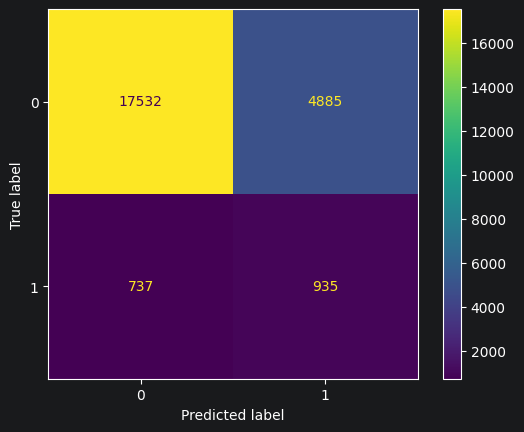

In [111]:
actual = y_test
threshold = 0.1
y_pred_custom = (y_probability_xgb >= threshold).astype(int)
print(classification_report(y_test, y_pred_custom))

confusion_matrix_xgb = confusion_matrix(actual, y_pred_custom)
cm_display = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_xgb, display_labels=[0, 1])
cm_display.plot()
plt.show()

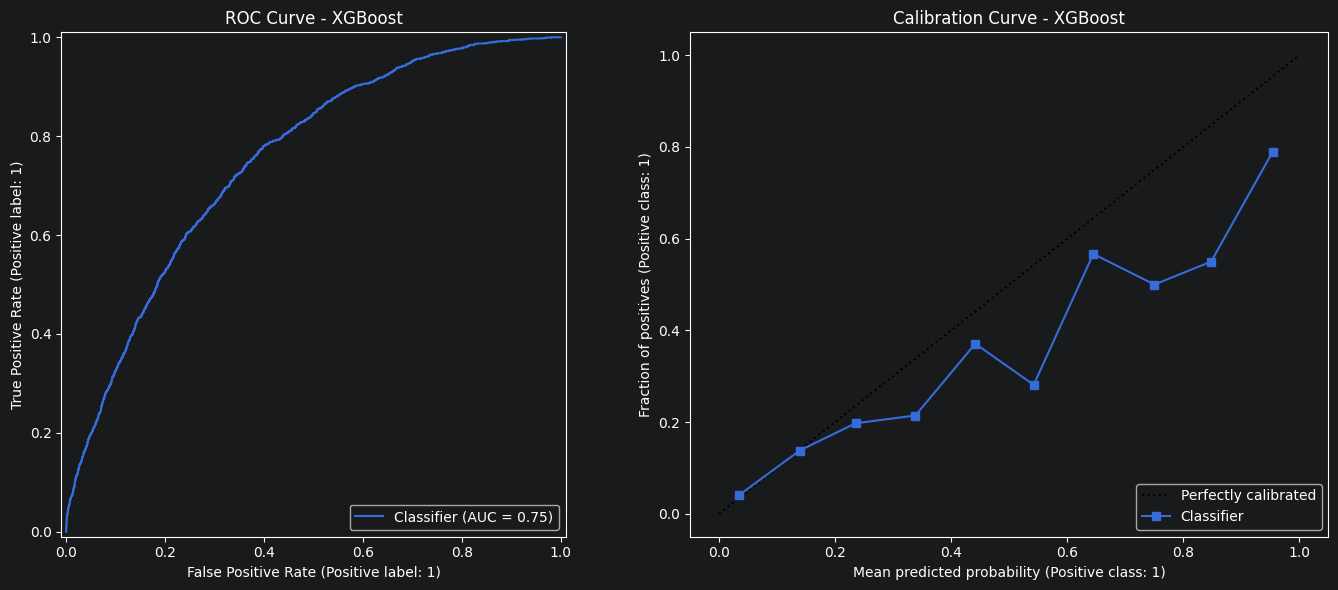

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_probability_xgb, ax=axes[0])
axes[0].set_title('ROC Curve - XGBoost')

# Calibration Curve
CalibrationDisplay.from_predictions(y_test, y_probability_xgb, n_bins=10, ax=axes[1])
axes[1].set_title('Calibration Curve - XGBoost')

plt.tight_layout()
plt.show()

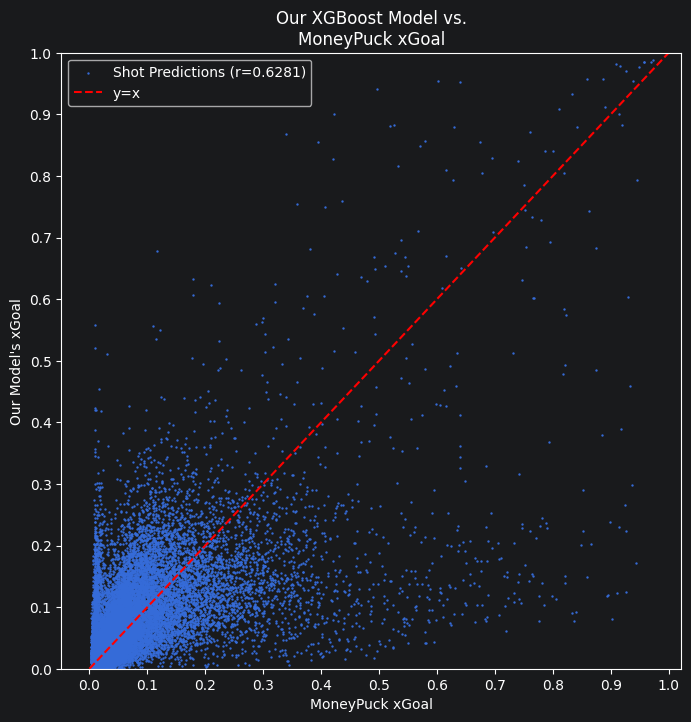

[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
Pearson Correlation: 0.6281


In [113]:
xgoal_moneypuck = df.loc[X_test.index, 'xGoal']
plt.figure(figsize=(8, 8))
ticks = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
correlation = np.corrcoef(xgoal_moneypuck, y_probability_xgb)[0, 1]
plt.scatter(xgoal_moneypuck, y_probability_xgb, s=.5, label=f'Shot Predictions (r={correlation:.4f})')
plt.xlabel('MoneyPuck xGoal')
plt.ylabel('Our Model\'s xGoal')
plt.xticks(ticks, ticks)
plt.yticks(ticks, ticks)
plt.title('Our XGBoost Model vs.\nMoneyPuck xGoal')
plt.axline((0, 0), slope=1, color='red', linestyle='--', label='y=x')
plt.ylim(0, 1)
plt.legend()
plt.show()
print(ticks)

print(f"Pearson Correlation: {correlation:.4f}")

In [114]:
joblib.dump(lr_model, '../models/lr_model.pkl')
joblib.dump(rf_model, '../models/rf_model.pkl')
joblib.dump(xgb_model, '../models/xgb_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

['../models/scaler.pkl']

In [115]:
dist_last_event_avg = df['distanceFromLastEvent'].mean()